## The Drought Fingerprint Plot
## Jupyter Notebook release version 1.0

This python notebook retrieves precipitation data from the Applied Climate Information System (https://www.rcc-acis.org/docs_webservices.html) and generates and saves a drought fingerprint plot from the retrieved data.

There is no user interface.  The user changes the values of certain variables at the beginning of cell 3 to specify the station and graphics file destination and (optionally) changes the values at the beginning of cell 4 to adjust certain aspects of the data processing and graphics.

The original version (let's call it V 0.1) was written by John Nielsen-Gammon (n-g@tamu.edu) and was distributed starting January 24, 2025.  

Version 0.2 was created on February 25, 2025.  It incorporates the experimental SPIeff and SPIrunoff, with accumulated precipitation partitioned into effective precipitation and runoff-producing precipitation, respectively.  See the 'effect' documentation for details.

This version (1.0) was posted in its Github repository on May 15, 2026.

Please send implemented or suggested improvements to John.  An online version of this tool is hosted by the Southern Regional Climate Center (https://srcc.tamu.edu) in its Climate Data Portal. Research or development collaborations are welcome.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
from dateutil.relativedelta import relativedelta
import urllib.request, urllib.error
import contextlib
import socket
import requests
import json

In [2]:
def get_cumsum(raw_data, input_end_date, max_ts, missing='cumulative', enforce_date = False, form='SPI'):
    # Calculate the cumulative precipitation total ending on specified date
    # Added form 2-25-25

    if missing not in ('cumulative','instance'):
        print('I do not know what missing = ',missing,'means -- aborting.')
        return
    end_dt = input_end_date
    try:      # Get ending row number; date might be string or datetime object
        edloc = raw_data.index.get_loc(input_end_date)
    except:
        try:
            edloc = raw_data.index.get_loc(dt.datetime.strftime(input_end_date,'%Y-%m-%d'))
        except:
            if end_force:
                # add missing data to raw_data to get to input_end_date
                print('sorry, not implemented')
            #else:
            edloc = len(raw_data) - 1                # If the requested date doesn't exist, use the latest date available
            print(input_end_date,'does not exist, using most recent date')
            end_dt = raw_data.index[-1]

    # Figure out how far back to go
    sloc = edloc - max_ts 
    sloc = max(sloc,0)

    # Get the precip data and missing data info; rearrange so first element is most recent day
    subset = raw_data[sloc:edloc+1]
    pser = subset['Precipitation'].tolist()
    mser = subset['Missing'].tolist()

    # Added next block of code 2-25-25 John N-G
    if form == 'SPIeff':
        df = pd.DataFrame(pser, columns=['pcpn'])
        pser = df.pcpn.rolling(6).apply(effect_wrapper,kwargs={'output':'fi'}).to_list()
    elif form == 'SPIrunoff':
        df = pd.DataFrame(pser, columns=['pcpn'])
        pser = df.pcpn.rolling(6).apply(effect_wrapper,kwargs={'output':'q'}).to_list()
        
    pser.reverse()
    mser.reverse()
    
    cser = [pser[0],]
    cm = mser[0]
    cmfr = [cm,]
    for i in range(1,len(pser)):
        cser.append(cser[i-1] + pser[i])   # Calculate cumulative precipitation sum
        if missing == 'cumulative':
            cm += mser[i]
            cmfr.append(cm/(i+1.))             # Calculate fraction of missing obs
        elif missing == 'instance':
            cmfr.append(mser[i])
    return cser, cmfr, end_dt

def Jan_1(input_end_dt,ndays):
    # Figure out which cumulative days correspond to changing years
    
    ny = []
    yoffset = 0
    while True:
        tdif = input_end_dt - dt.datetime(input_end_dt.year-yoffset,1,1)
        ddif = tdif.days
        if ddif > ndays:
            return ny
        ny.append(ddif)
        yoffset += 1

def day_1(input_end_dt,ndays,nmos):
    # Figure out which cumulative days correspond to changing months
    
    nm = []
    moffset = 0
    yoffset = 0
    i = 0
    motxt = []
    while True:
        midofmonth = dt.datetime(input_end_dt.year-yoffset,input_end_dt.month-moffset,15)
        tdif = input_end_dt - midofmonth
        ddif = tdif.days
        if ddif > ndays:      # Fail-safe; should never happen unless nmos is bad input
            return nm, motxt
        if ddif >= 0:
            nm.append(ddif)
            motxt.append(dt.datetime.strftime(midofmonth,'%b'))
            i += 1
        moffset += 1
        if i == nmos:
            return nm, motxt
        if input_end_dt.month - moffset < 1:
            moffset -= 12
            yoffset += 1

def cleanup(df,space=''):
    # Get raw dataframe into ship shape by handling traces, missing precip, and multi-day totals
    
    df.loc[df.Precipitation == space+'T','Precipitation'] = '0.00'
    df['Missing'] = 0
    df.loc[df.Precipitation == space+'M','Missing'] = 1
    df.loc[df.Precipitation == space+'M','Precipitation'] = '0.00'
    plst = df['Precipitation'].to_list()
    for i,p in enumerate(plst):                                     # Spread multiday reports out over the multi days
        if p[-1] == 'A':
            ptot = float(p[:-2])
            j=i-1
            while j >= 0:
                if plst[j] != space+'S':
                    break
                j -= 1
            pday = ptot/(i-j)
            for k in range(j,i):
                plst[k+1] = f'{pday:6.3f}'
    df.Precipitation = plst
    df.loc[df.Precipitation == space+'S','Missing'] = 1              # Sometimes there's an 'S' without a corresponding 'A'
    df.loc[df.Precipitation == space+'S','Precipitation'] = '0.00'
    df.Precipitation = df.Precipitation.astype(float)
    return df

def fill_plots(ax1, ax2, y1, y2, label, color, short=180, x=0, zorder=1):
    # Utility subroutine to fill the area between two (percentile) lines on each of two axes (panels).
    
    if x==0:
        ax1.fill_between(range(short), y1[:short], y2[:short], label=label, alpha=1.0, color=color, zorder=zorder)
        ax2.fill_between(range(len(y1)), y1, y2, label=label, alpha=1.0, color=color, zorder=zorder)
    else:
        if x < short:
            ax1.fill_between([x,x+1], y1, y2, alpha=1.0, label=label, color=color, zorder=zorder)
        ax2.fill_between([x,x+1], y1, y2, alpha=1.0, label=label, color=color, zorder=zorder)
    return

# Calculate effective precipitation and runoff
def effect(p):
    '''
    Calculates effective precipitation and runoff using a modified curve number approach
    Based on M.G. Bos et al. 2009 Water Requirements for Irrigation and the Environment (Springer)
      but using inches rather than millimeters

    Except:
    Assumes uniform soil conditions with reference curve number cnref
    Does not differentiate between growing and dormant seasons, using intermediate values instead
    Estimates that initial precip Io may be lost to evaporation, 
      where Io = pl * min (ne, preceding consecutive days <= pl)

    Input:
    p: current and five preceding days of precipitation, in numpy array (current day is p[-1])

    Output:
    Dictionary with effective precipitation (fi) and runoff (q)

    Future work:
    Differentiate between growing and dormant seasons
    Make initial precipitation loss dependent on climatological vpd or other measure of pet or growing/dormant seasons
    Use curve number reference value from reliable source (USDA? DSSAT?)
    '''
    pl = 0.05 # precipitation reference value in initial precip formula
    ne = 3    # max number of days in initial precip formula; cannot be larger than input array - 1
              # Note: maximum initial precip loss is ne*pl
    cnref = 74  # reference curve number value
    cnlow = 55
    cnhigh = 88
    amclow = 1.   # if 5-day precip less than this, use low curve number
    amchigh = 1.6 # if 5-day precip more than this, use high curve number

    # shortcuts
    psum = np.sum(p[:-1])
    #pob = p[-1]  # Dunno why this doesn't work
    pob = np.sum(p[-1:])
    if np.isnan(psum) or np.isnan(pob):
        return({'fi':np.nan,'q':np.nan})
    if pob == 0:
        return({'fi':0.,'q':0.})

    plist = list(p)
    if psum < amclow:
        cn = cnlow
    elif psum > amchigh:
        cn = cnhigh
    else:
        cn = cnref
    s = -1. + 100/cn
    
    Io = 0
    for i in range(2,5):
        #if p[-i] <= pl:
        #if np.sum(p[-i]) <= pl:     # Same dunno problem as above
        if plist[-i] <= pl:
            Io += pl
        else:
            break
            
    a = max(pob - Io, 0)
    Ia = 0.2 * s
    if pob <= Ia:
        return({'fi':a,'q':0.})
    q = (pob-Ia)*(pob-Ia)/(pob-Ia+s)
    fi = a - q
    return({'fi':fi,'q':q})

def effect_wrapper(p,output='both'):    # need this until rolling.apply can handle dictionary function output
    efdict = effect(p)
    if output == 'fi':
        return(efdict['fi'])
    elif output == 'q':
        return(efdict['q'])
    elif output == 'both':
        return(efdict)
    else:
        print('effect_wrapper does not know what to do')
        return(-1)


### Beginning of user inputs
This cell retrieves the data from ACIS and cleans it up.  Specify the `station` you wish to analyze as a station ID string recognizable to ACIS.  
METAR example: `"KCLL"`.  
ThreadEX example: `"lbbthr"`.  
USHCN example: `"419295"`.

Sometimes (or often), the station you wish to analyze doesn't have a very long period of record.  This would make the historical percentiles unreliable.  You have the option of specifying a different nearby station for the historical percentile climatology using the variable `historical`.

A smart program would retrieve the station name from the ACIS call, but this program requires you to specify the station name as `sname`.  If you fail to do so, the title of your plot will be wrong.

In [3]:
# Production cell #1: Download and prepare data
# ************************************* Start of User Inputs for This Cell ************************************
station = 'tlhthr'
historical = None      # Use this if your target station has a suitably long period of record
#historical = '412906'  # Use this if your target station doesn't have a suitably long period of record
sname = station         
sname = 'Tallahassee, FL'
savefigprefix = ''     # graphics filename will be 
                                      # savefigprefix+station+'.png'; use '' to not save graphics to file
# ************************************* End of User Inputs for This Cell ************************************

while True:             # While loop that will infinitely retry to get the data from the given url.
    try:                # Will move on as soon as it does not time out and receives a response.
        with contextlib.closing(urllib.request.urlopen('http://data.rcc-acis.org/StnData?sid='+station+
                                                       '&sdate=por&edate=por&elems=pcpn', 
                                                       timeout=30)) as response:
            a = response.read().decode('utf-8')
            z = json.loads(a)
            break
    except socket.timeout:
        # In the case of the request timing out, notifies the user of timeout and retries the request.
        print("Timed Out: Retrying request")
        pass
    except urllib.error.URLError:
        # In the case of the request failing, notifies the user of the failure and retries the request.
        print("Request Failed: Retrying request")
        pass
raw_data = pd.DataFrame(z['data'],columns=['Date','Precipitation']).set_index('Date')
raw_data = cleanup(raw_data)

if historical != None:  # Block added Aug 13
    while True:             # While loop that will infinitely retry to get the data from the given url.
        try:                # Will move on as soon as it does not time out and receives a response.
            with contextlib.closing(urllib.request.urlopen('http://data.rcc-acis.org/StnData?sid='+historical+
                                                           '&sdate=por&edate=por&elems=pcpn', 
                                                           timeout=30)) as response:
                a = response.read().decode('utf-8')
                z = json.loads(a)
                break
        except socket.timeout:
            # In the case of the request timing out, notifies the user of timeout and retries the request.
            print("Timed Out: Retrying request")
            pass
        except urllib.error.URLError:
            # In the case of the request failing, notifies the user of the failure and retries the request.
            print("Request Failed: Retrying request")
            pass
    hist_data = pd.DataFrame(z['data'],columns=['Date','Precipitation']).set_index('Date')
    hist_data = cleanup(hist_data)

print('Most recent week')
raw_data.tail(7)

Most recent week


,Precipitation,Missing
Date,,
2026-05-07,0.04,0
2026-05-08,0.00,0
2026-05-09,0.18,0
2026-05-10,0.00,0
2026-05-11,0.03,0
2026-05-12,1.55,0
2026-05-13,0.00,0


### Other user settings
Now that the data has been obtained (and the most recent week of available data displayed above), it's time for the program to generate the plot.  Here you can specify a plot for a different date other than the most recent available and specify how many years should be included in the right-hand plot.

Plots can be of the total precipitation (the standard approach, analogous to the SPI) or of a portion of the precipitation allocated using a simple curve number approach (M.G. Bos et al. 2009 Water Requirements for Irrigation and the Environment (Springer)).  The portion plotted can be either effective precipitation (the amount estimated to infiltrate into the soil and be available for transpiration) or runoff (the amount estimated to run off without infiltrating).  In all cases, the historical precipitation percentiles are based on the same precipitation allocation.  Because infiltration moisture tends to be relevant for shorter agricultural time scales, the default length of time for the right-hand plot is two years rather than five years. The particular plot desired (SPI, SPIeff, or SPIrunoff) is specified by the parametjer `form`.

The percentile calculation includes the input parameter `mas_mis_frac`, or the maximum percentage of missing data.  A low maximum percentage means that the program will ignore incomplete data in its calculation, possibly limiting the number of historical years available; a high maximum percentage means that the program will include years with lots of missing data and hence will underestimate the normal amount of precipitation.  There's no "correct" value; I like 0.10 (ten percent).

Another input parameter, `topwet`, affects the plotting style of the right-hand plot.  If true, the right-hand plot extends up to the record highest precipitation amount over the accumulation interval.  This can leave much of the top part of the plot irrelevant to the interpretation of the observed precipitation graph, compressing its information into the bottom part of the plot.  If false (default), the top of the graph is defined by the larger of the median accumulated precipitation and the observed accumulated precipitation.

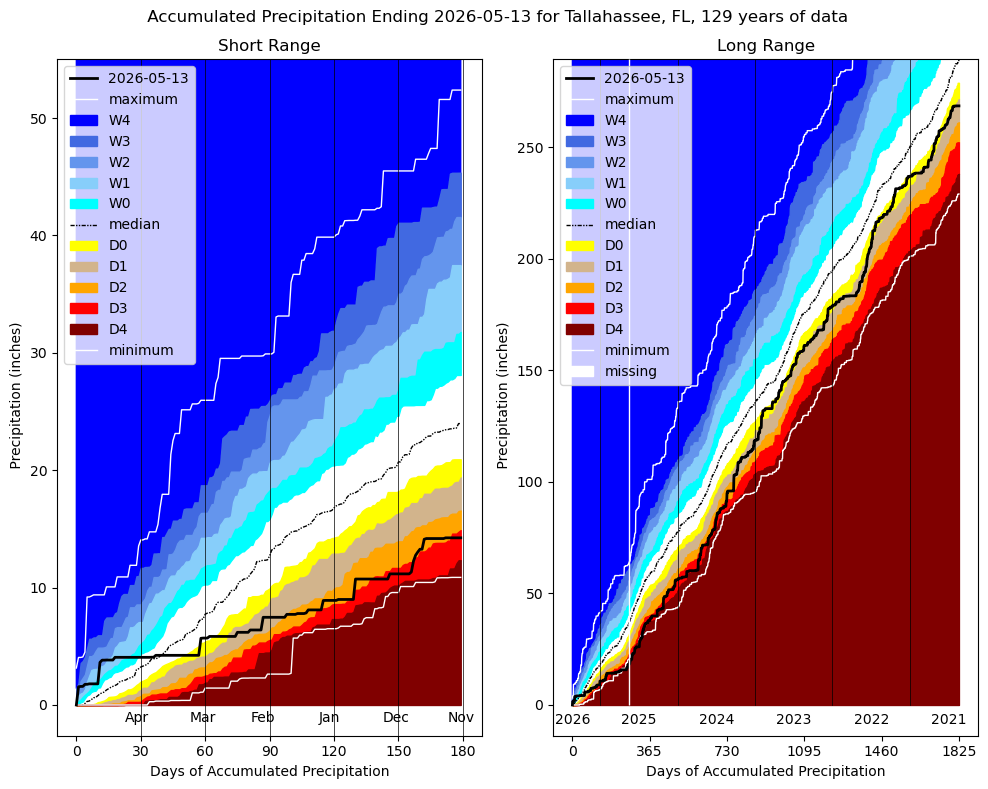

In [4]:
#********************** User Input Data for This Cell *****************************#
input_end_date = 'latest'     # Use the most recent available data as the end date for the plot
#input_end_date = '1956-06-25'     # or specify the end date for the plot
#end_force = True                  # Not implemented: require specified end date even if data doesn't exist
#form = 'SPIeff'            
form = 'SPI'
#form = 'SPIrunoff'
display = '2panel'     # otherwise, separate plots
topwet = False         # True shows full range in 2nd plot, False shows up to actual
end_force = False
if form == 'SPIeff':   
    maxyr = 2                         # The number of years to plot in the long-term panel
else:
    maxyr = 5
max_mis_frac = 0.10               # Choose maximum fraction of missing data 
missing = 'instance'
#missing = 'cumulative'
#*********************** End of User Input Data for This Cell ************************#

ptype = {'SPI' : '',
         'SPIeff' : 'EFFECTIVE',
         'SPIrunoff':'RUNOFF'}    
max_ts = 365*maxyr
if input_end_date == 'latest':
    end_date = raw_data.index[-1]
else:
    end_date = input_end_date
input_end_dt = dt.datetime.strptime(end_date,'%Y-%m-%d')
cser, mser, end_dt = get_cumsum(raw_data, input_end_dt, max_ts, 
                                missing=missing, enforce_date=end_force,
                                form=form)   # Added form 2-25-25
try:
    end_date = dt.datetime.strftime(end_dt,'%Y-%m-%d')
except:
    end_date = end_dt
    end_dt = dt.datetime.strptime(end_date,'%Y-%m-%d')

if display == '2panel':
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10, 8))   # two-panel plot
else:
    fig, (ax1) = plt.subplots(figsize=(10, 8))   # separate plots (added 2-25-25)
    fig, (ax2) = plt.subplots(figsize=(10, 8))

other_years=[]
if historical == None:  # added block with Else; should convert to subroutine
    sdate = raw_data.index[0][:4]+end_date[4:]      # The starting date for the earliest period is either the specified  
    sdt = dt.datetime.strptime(sdate,'%Y-%m-%d')          # month and day of the earliest year in the data, or the year after
    if sdate < raw_data.index[0]:    
        sdt += relativedelta(years=1)      
    while True:
        if sdt > dt.datetime.strptime(raw_data.index[-1],'%Y-%m-%d'):     # All done if we try to access data in the future
            break
        if sdt == end_dt:                                           # Don't include the requested year in the percentile calculations
            sdt += relativedelta(years=1)
            continue
        ocser, omser, dtime = get_cumsum(raw_data, sdt, max_ts, form=form)  # Added form 2-25-25
        ocser = [x if y<max_mis_frac else np.nan for x,y in zip(ocser, omser)]    # If too much 
        year = dt.datetime.strftime(sdt,'%Y')
        other_years.append(ocser)
        sdt += relativedelta(years=1)
else:
    sdate = hist_data.index[0][:4]+end_date[4:]      # The starting date for the earliest period is either the specified  
    sdt = dt.datetime.strptime(sdate,'%Y-%m-%d')          # month and day of the earliest year in the data, or the year after
    if sdate < hist_data.index[0]:    
        sdt += relativedelta(years=1)      
    while True:
        if sdt > dt.datetime.strptime(hist_data.index[-1],'%Y-%m-%d'):     # All done if we try to access data in the future
            break
        if sdt == end_dt:                                           # Don't include the requested year in the percentile calculations
            sdt += relativedelta(years=1)
            continue
        ocser, omser, dtime = get_cumsum(hist_data, sdt, max_ts, form=form)  # Added form 2-25-25
        ocser = [x if y<max_mis_frac else np.nan for x,y in zip(ocser, omser)]    # If too much 
        year = dt.datetime.strftime(sdt,'%Y')
        other_years.append(ocser)
        sdt += relativedelta(years=1)

oyl = max(map(len, other_years))
oy = np.array([x+[np.nan]*(oyl-len(x)) for x in other_years])         # Make numpy array, dealing with some short years

ax1.plot(cser[:180],label=end_date,lw=2,c='black',zorder=2.5)               # Plot desired cumulative precipitation 
ax2.plot(cser,label=end_date,lw=2,c='black',zorder=2.5)                    
                                                # Future option: fill missing values with median increments

p100 = np.nanpercentile(oy,100,axis=0,method='median_unbiased')        # Plot historic maximum
ax1.plot(p100[:180],label='maximum',lw=1,c='white')
ax2.plot(p100,label='maximum',lw=1,c='white')

p98 = np.nanpercentile(oy,98,axis=0,method='median_unbiased')          # Plot shaded historic wet percentiles
fill_plots(ax1, ax2, [np.nanmax(p100)]*len(cser), p98, 'W4', 'blue')
p95 = np.nanpercentile(oy,95,axis=0,method='median_unbiased')
fill_plots(ax1, ax2, p98, p95, 'W3', 'royalblue')
p90 = np.nanpercentile(oy,90,axis=0,method='median_unbiased')
fill_plots(ax1, ax2, p95, p90, 'W2', 'cornflowerblue')
p80 = np.nanpercentile(oy,80,axis=0,method='median_unbiased')
fill_plots(ax1, ax2, p90, p80, 'W1', 'lightskyblue')
p70 = np.nanpercentile(oy,70,axis=0,method='median_unbiased')
fill_plots(ax1, ax2, p80, p70, 'W0', 'cyan')

p50 = np.nanpercentile(oy,50,axis=0,method='median_unbiased')         # Plot historic median
ax1.plot(p50[:180],label='median',linestyle= (0, (3, 1, 1, 1, 1, 1)),lw=1,c='black')  # Linestyle added 2-25-25
ax2.plot(p50,label='median',linestyle= (0, (3, 1, 1, 1, 1, 1)),lw=1,c='black')   # Linestyle added 2-25-25
p30 = np.nanpercentile(oy,30,axis=0,method='median_unbiased')
p20 = np.nanpercentile(oy,20,axis=0,method='median_unbiased')
fill_plots(ax1, ax2, p20, p30, 'D0', 'yellow')
p10 = np.nanpercentile(oy,10,axis=0,method='median_unbiased')
fill_plots(ax1, ax2, p10, p20, 'D1', 'tan')
p05 = np.nanpercentile(oy,5,axis=0,method='median_unbiased')
fill_plots(ax1, ax2, p05, p10, 'D2', 'orange')
p02 = np.nanpercentile(oy,2,axis=0,method='median_unbiased')
fill_plots(ax1, ax2, p02, p05, 'D3', 'red')
p00 = np.nanpercentile(oy,0,axis=0,method='median_unbiased')
fill_plots(ax1, ax2, [0]*len(cser), p02, 'D4', 'maroon')

ax1.plot(p00[:180],label='minimum',lw=1,c='white')                     # Plot historic minimum
ax2.plot(p00,label='minimum',lw=1,c='white')

#ax2.set_ylim(top=max(cser))  #long range y limit set to max precip sum added 2-25-25
ax1top = max(np.nanmax(p100[:180])*(21/20),np.nanmax(cser[:180])*(21/20))   # Changed 4 lines to nanmax 2-25-25
ax1bot = min(np.nanmax(p100[:180])*(-1/20),np.nanmax(cser[:180])*(-1/20))
if topwet:                  # added 2-25-25
    ax2top = max(np.nanmax(p100),np.nanmax(cser))
else:
    ax2top = max(np.nanmax(cser),np.nanmax(p50))
    ax2bot = ax2top*(-1/21.)

mlabel = 'missing'
for i,m in enumerate(mser):                                      # White out data gaps
    if m==1:
        fill_plots(ax1, ax2, [ax2top]*2, [0,0], mlabel, 'white', x=i, zorder=2.6)
        mlabel = None     # only one 'missing' label in legend

newyears = Jan_1(end_dt,max_ts)                                  # Identify year boundaries
ys = int(end_date[:4])
yloc = 0 - np.nanmax(p100)/100.                       # Changed to nanmax 2-25-25
for ny in newyears:
    ax2.plot([ny, ny], [0, ax2top], color="black", lw=0.5, zorder=2.7)
    if ny > 182:
        ax2.text(ny-182,yloc,str(ys),horizontalalignment='center',verticalalignment='top')
    else:
        ax2.text(0,yloc,str(ys),horizontalalignment='center',verticalalignment='top')
    ys -= 1
    # *****  Added 1-10-2025 J N-G  *****
    if ny == newyears[-1]:
        if ny-182 < max_ts-365:
            ax2.text(ny+182,yloc,str(ys),horizontalalignment='center',verticalalignment='top')


for ny in range(30,200,30):                                        # Identify 30-day boundaries
    ax1.plot([ny, ny], [ax1bot, ax1top], color="black", lw=0.5, zorder=2.7)

yloc = 0 - np.max(p100[:180])/100.                                      # Plot month labels
xmos, motxt = day_1(end_dt,max_ts,6)
for xm, mt in zip(xmos, motxt):
    if xm > 0:
        ax1.text(xm,yloc,mt,horizontalalignment='center',verticalalignment='top')

ax1.set_ylim([ax1bot,ax1top])   # Make plots prettier
ax1.xaxis.set_ticks(range(0,190,30))
ax1.set_xlabel('Days of Accumulated Precipitation')
ax1.set_ylabel(ptype[form]+' Precipitation (inches)')  # Added ptype 2-25-25
ax1.legend(loc='upper left')
if display == '2panel':                # Added if 2-25-25
    ax1.set_title('Short Range')

ax2.set_ylim([ax2bot,ax2top])
ax2.xaxis.set_ticks(range(0,maxyr*365+5,365))        # Changed 2-25-25
ax2.set_xlabel('Days of Accumulated Precipitation')
ax2.set_ylabel(ptype[form]+' Precipitation (inches)')  # Added ptype 2-25-25
if display == '2panel':               # Added if 2-25-25
    ax2.set_title('Long Range')
    ax2.legend(loc='upper left')
else:
    ax2.legend(loc='lower right', facecolor = 'lightgray')

    
gyears = str(int((raw_data['Missing'] == 0).sum()/365.25))
relto = ''        # Aug 13 added relto functionality to next 8 lines of code
if historical != None:
    relto = 'using '+historical+' for '
    gyears = str(int((hist_data['Missing'] == 0).sum()/365.25))
if display == '2panel':                       # Added if 2-25-25
    fig.suptitle(ptype[form]+' Accumulated Precipitation Ending '+
                 end_date+' for '+sname+', '+relto+gyears+' years of data') #Added ptype 2-25-25
else:
    ax1.set_title(ptype[form]+' Accumulated Precipitation Ending '+
                  end_date+' for '+sname+', '+relto+gyears+' years of data\n Short Range') #Added ptype 2-25-25
    ax2.set_title(ptype[form]+' Accumulated Precipitation Ending '+
                  end_date+' for '+sname+', '+relto+gyears+' years of data\n Long Range') #Added ptype 2-25-25

plt.tight_layout()
if len(savefigprefix) > 0:
    plt.savefig(savefigprefix+station+ptype[form]+'.png',dpi=300)   # Added 2-25-25
plt.show()

### Explanation of Drought Fingerprint Plots
The fingerprint plots shown above (if the program worked) are designed to put short-term and long-term precipitation deficits into historical context.  The left-hand plot shows the most recent six months up to the ending time of the plot; the right-hand plot shows the most recent five years (can be changed by user).  

The thick black line shows the cumulative precipitation over the number of days specified on the x axis and ending on the date indicated in the title.  For ease of interpretation, the x axis is also labeled with the month or year corresponding to that many days before the date indicated in the title.  Thin vertical black lines are drawn at 30-day increments in the left plot and mark calendar years in the right plot.

The other background lines and colors indicate the historical climatology.  The medium-width black line is the median and the top and bottom white lines are the historic high and low records.  These records do not include the values on the thick black line so that one can identify record-breaking epochs and their magnitudes.  The other colors are percentiles.  On the dry side, the percentiles correspond to the levels in the US Drought Monitor and are shown using the same colors: 20%-30% = D0, 10%-20% = D1, 5%-10% = D2, 2%-5% = D3, and <2% = D4.  The percentiles on the wet side are mirror opposites: 70%-80% = W0, etc.

One could, knowing the SPI values that correspond to the USDM category cutoffs, estimate the SPI for any desired accumulation period.  The only difference is that these plots show historical actual percentiles rather than percentiles derived from a probability distribution fitted to historical data.  (The Climate Engine uses historical actual percentiles but calls the result an SPI. To avoid confusion it would be better to call something like this a non-parametric SPI; see Farahmand and AghaKouchak 2025 https://doi.org/10.1016/j.advwatres.2014.11.012 .)

In [7]:
raw_data

,Precipitation,Missing
Date,,
1893-01-17,0.3,0
1893-01-18,0.0,1
1893-01-19,0.0,1
1893-01-20,0.0,1
1893-01-21,0.0,1
...,...,...
2025-08-06,0.0,0
2025-08-07,0.0,0
2025-08-08,0.0,0


In [14]:
ocser, omser, dtime = get_cumsum(raw_data, dt.date(1893,8,11), 20, form=form)

In [15]:
ocser

[0.0,
 0.7,
 3.33,
 3.33,
 4.72,
 4.72,
 4.72,
 4.72,
 4.72,
 4.72,
 4.72,
 5.6,
 5.6,
 5.6,
 5.6,
 5.6,
 5.6,
 5.6,
 6.17,
 6.17,
 6.17]

In [16]:
omser

[1,
 0.5,
 0.3333333333333333,
 0.5,
 0.4,
 0.5,
 0.5714285714285714,
 0.625,
 0.6666666666666666,
 0.7,
 0.7272727272727273,
 0.6666666666666666,
 0.6923076923076923,
 0.7142857142857143,
 0.7333333333333333,
 0.75,
 0.7647058823529411,
 0.7777777777777778,
 0.7368421052631579,
 0.75,
 0.7142857142857143]

In [10]:
[x[0:5] for x in other_years]

[[0.7, 3.33, nan, nan, nan],
 [nan, nan, nan, nan, nan],
 [nan, nan, nan, nan, nan],
 [nan, nan, nan, nan, nan],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 1.38, 1.38],
 [nan, nan, nan, nan, nan],
 [nan, nan, nan, nan, nan],
 [nan, nan, nan, nan, nan],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.53, 0.53, 0.53, 0.53, 0.53],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.15],
 [0.0, 1.52, 1.52, 1.52, 1.52],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [nan, nan, nan, nan, nan],
 [nan, nan, nan, nan, nan],
 [0.7, 0.7, 0.7, 0.7, 0.7],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [1.45, 1.45, 1.45, 1.45, 1.45],
 [0.0, 1.0, 1.4, 1.4, 1.4],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.4, 0.6000000000000001, 0.6000000000000001],
 [0.0, 0.0, 0.3, 0.3, 0.3],
 [nan, nan, nan, nan, nan],
 [nan, nan, nan, nan, nan],
 [nan, nan, nan, nan, nan],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.5, 1.0, 1.5, 2.15],
 [0.0, 0.0, 0.0, 0.0, 0.0],

In [12]:
dt.date(1893,8,11)

datetime.date(1893, 8, 11)

In [17]:
raw_data

,Precipitation,Missing
Date,,
1893-01-17,0.3,0
1893-01-18,0.0,1
1893-01-19,0.0,1
1893-01-20,0.0,1
1893-01-21,0.0,1
...,...,...
2025-08-06,0.0,0
2025-08-07,0.0,0
2025-08-08,0.0,0


In [18]:
raw_data[:5]

,Precipitation,Missing
Date,,
1893-01-17,0.3,0
1893-01-18,0.0,1
1893-01-19,0.0,1
1893-01-20,0.0,1
1893-01-21,0.0,1
